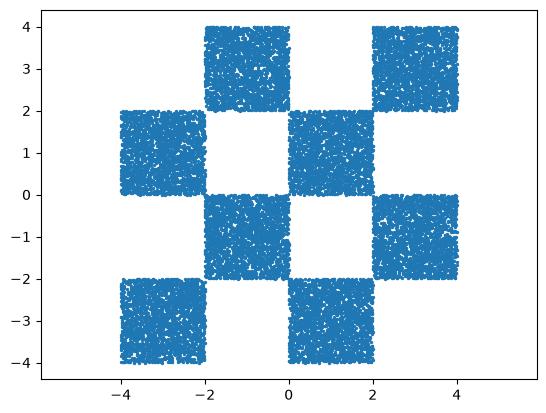

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def checkerboard(n, seed=11):
    rng = np.random.default_rng(seed)

    centres = np.array([
        [-3,  1], [-3, -3],
        [-1,  3], [-1, -1],
        [ 1,  1], [ 1, -3],
        [ 3,  3], [ 3, -1],
    ])

    tiles = rng.integers(0, 8, size=n)
    offsets = rng.uniform(-1, 1, size=(n, 2))

    return centres[tiles] + offsets


checkerboard_data = checkerboard(20000)
data = checkerboard_data

plt.scatter(checkerboard_data[:, 0], checkerboard_data[:, 1], s=2)
plt.title("Checkerboard data")
plt.axis("equal")
plt.show()

In [ ]:
def two_spirals(n, noise=0.12, seed=11):
    rng = np.random.default_rng(seed)

    angle = rng.uniform(0, 3 * np.pi, size=n)
    radius = 0.42 * angle
    arm = rng.choice((-1, 1), size=n)

    points = np.column_stack((
        radius * np.cos(angle),
        radius * np.sin(angle)
    ))

    points = arm[:, None] * points
    points += rng.normal(0, noise, size=(n, 2))
    return points


spiral_data = two_spirals(20000)

# The rest of the notebook uses this dataset.
# Change this to checkerboard_data to run the original reproduction.
data = spiral_data

plt.scatter(data[:, 0], data[:, 1], s=2)
plt.title("Two-spiral data")
plt.axis("equal")
plt.show()

Step 0, Loss: 12.3332
Step 1000, Loss: 6.9995
Step 2000, Loss: 6.9170
Step 3000, Loss: 6.8537
Step 4000, Loss: 6.5532
Step 5000, Loss: 6.9942
Step 6000, Loss: 6.7595
Step 7000, Loss: 6.7732
Step 8000, Loss: 6.7090
Step 9000, Loss: 6.5973


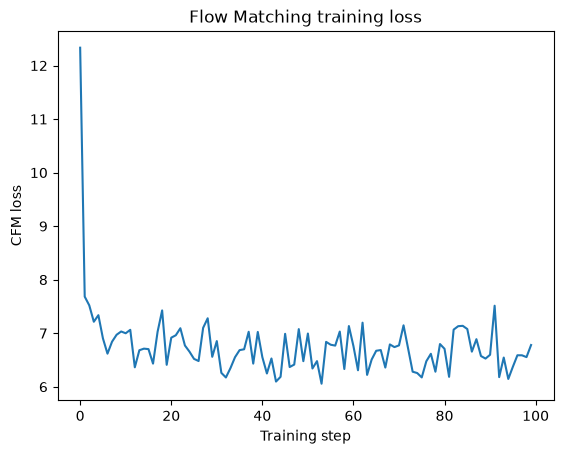

In [ ]:
import torch
from torch import nn

training_data = torch.tensor(data, dtype=torch.float32)

# The paper uses a MLP with 512-neuron layers
# This is a scaled down version for faster training & it still captures the main algorithm
def make_model():
    return nn.Sequential(
        nn.Linear(3, 128), # 3 inputs: time, x_t[0], x_t[1]
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 2), # 2 outputs: predicted_velocity[0], predicted_velocity[1]
    )


def train_model(data, sigma_min, training_steps=10000, batch_size=512, seed=11):
    torch.manual_seed(seed)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_history = []

    for step in range(training_steps):
        indices = torch.randint(len(data), (batch_size,))
        x_data = data[indices]

        noise = torch.randn_like(x_data)
        time = torch.rand(batch_size, 1)

        x_t = ((1 - (1 - sigma_min) * time) * noise) + (time * x_data)
        target_velocity = x_data - (1 - sigma_min) * noise

        model_input = torch.cat((time, x_t), dim=1)
        predicted_velocity = model(model_input)
        loss = ((predicted_velocity - target_velocity) ** 2).sum(dim=1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            loss_history.append(loss.item())

    return model, loss_history


baseline_sigma = 0.1
training_steps = 10000
batch_size = 512

model, loss_history = train_model(
    training_data,
    sigma_min=baseline_sigma,
    training_steps=training_steps,
    batch_size=batch_size
)

loss_steps = np.arange(0, training_steps, 100)
plt.plot(loss_steps, loss_history)
plt.xlabel("Training step")
plt.ylabel("CFM loss")
plt.title("Flow Matching training loss")
plt.show()

In [20]:
# Generate the points

@torch.no_grad()
def generate(model, number_of_points = 5000, steps = 10, return_path = False):
    x = torch.randn(number_of_points, 2)
    dt = 1 / steps
    
    if return_path:
        path = [x.clone()]
        save_steps = {steps // 3, 2 * steps // 3, steps}
    
    # Runge-Kutta 2nd order integration, maybe we could use a higher order? 
    for step in range(steps):
        time = torch.full((number_of_points, 1), step * dt)
        velocity = model(torch.cat((time, x), dim=1))
        x_mid = x + 0.5 * dt * velocity
        mid_time = time + 0.5 * dt
        mid_velocity = model(torch.cat((mid_time, x_mid), dim=1))
        x = x + dt * mid_velocity
        
        if return_path and (step + 1) in save_steps:
            path.append(x.clone())
    
    if return_path:
        return x, path
        
    return x


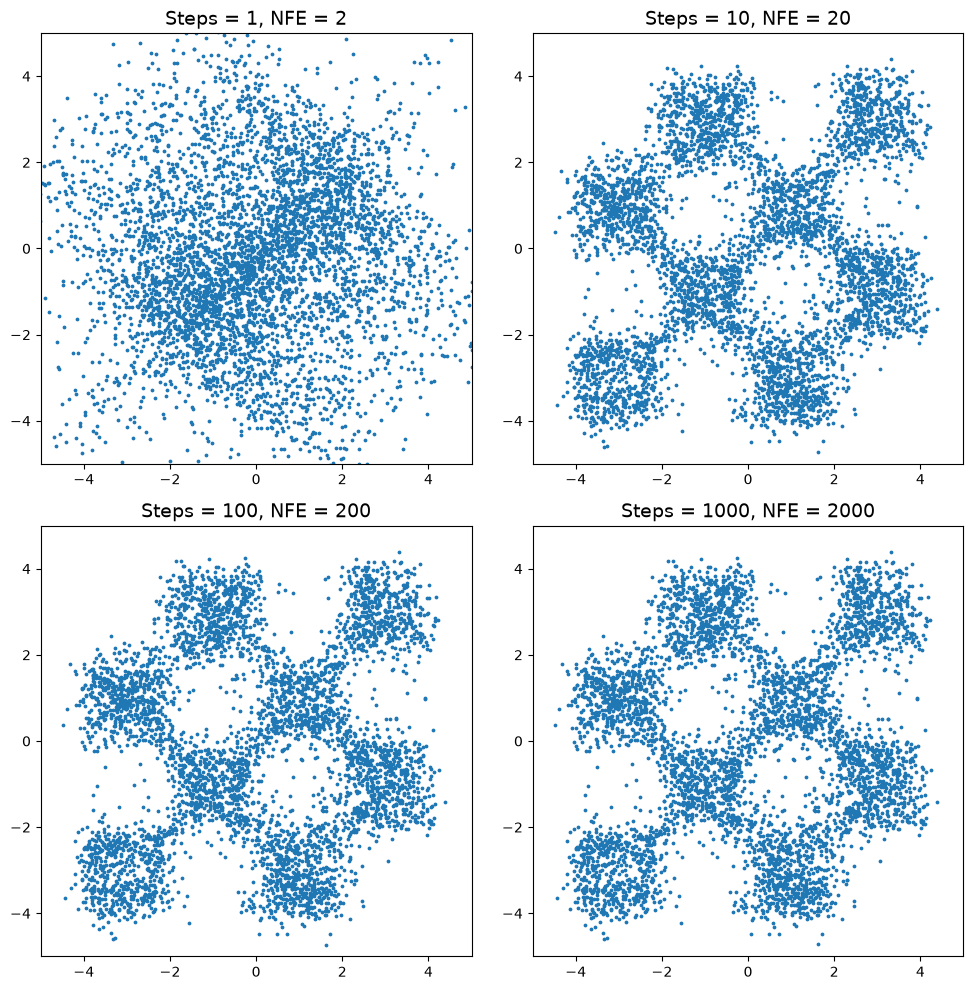

In [ ]:
model.eval()

steps_list = [1, 10, 100, 1000] # play around here to see how many steps you need


fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, steps in enumerate(steps_list):
    torch.manual_seed(123)

    generated = generate(
        model,
        number_of_points=5000,
        steps=steps
    ).numpy()

    axes[i].scatter(
        generated[:, 0],
        generated[:, 1],
        s=3
    )

    axes[i].set_title(
        f"Steps = {steps}, NFE = {2 * steps}",
        fontsize=14
    )
    axes[i].set_xlim(-5, 5)
    axes[i].set_ylim(-5, 5)
    axes[i].set_aspect("equal")

plt.tight_layout()
plt.show()

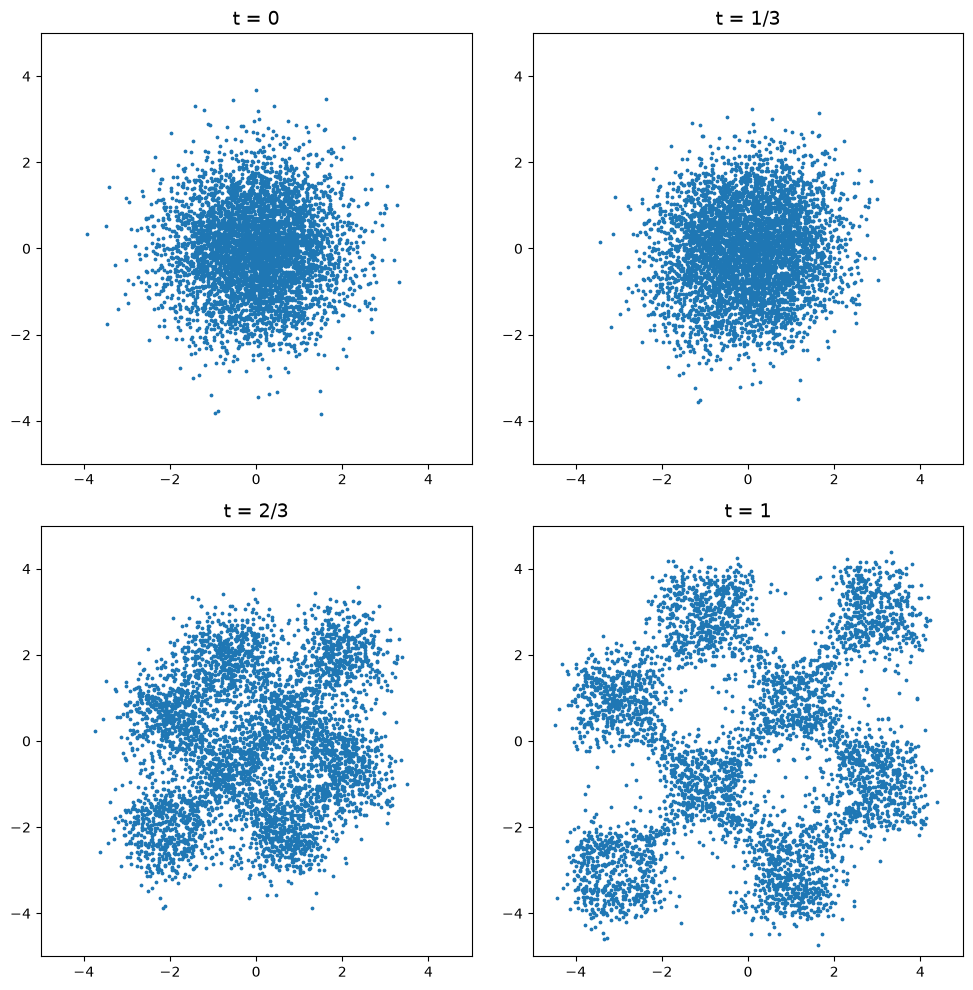

In [22]:
torch.manual_seed(123)

x, path = generate(
    model,
    number_of_points=5000,
    steps=60,
    return_path=True
)

time_labels = ["t = 0", "t = 1/3", "t = 2/3", "t = 1"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for axis, points, label in zip(
    axes,
    path,
    time_labels
):
    points = points.numpy()

    axis.scatter(points[:, 0], points[:, 1], s=3)
    axis.set_title(label, fontsize=14)
    axis.set_xlim(-5, 5)
    axis.set_ylim(-5, 5)
    axis.set_aspect("equal")

plt.tight_layout()
plt.show()

In [ ]:
# Variation: retrain the model for different endpoint noise levels
sigma_values = [0.01, 0.1, 0.3]
sigma_models = []

for sigma in sigma_values:
    if sigma == baseline_sigma:
        sigma_model = model
    else:
        print(f"Training with sigma_min = {sigma}")
        sigma_model, _ = train_model(
            training_data,
            sigma_min=sigma,
            training_steps=training_steps,
            batch_size=batch_size
        )

    sigma_models.append(sigma_model)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for axis, sigma, sigma_model in zip(axes, sigma_values, sigma_models):
    torch.manual_seed(123)
    sigma_model.eval()
    generated_sigma = generate(
        sigma_model,
        number_of_points=5000,
        steps=10
    ).numpy()

    axis.scatter(generated_sigma[:, 0], generated_sigma[:, 1], s=3)
    axis.set_title(f"sigma_min = {sigma}", fontsize=14)
    axis.set_xlim(-5, 5)
    axis.set_ylim(-5, 5)
    axis.set_aspect("equal")

plt.tight_layout()
plt.show()